In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Our modules
from src.data_loader import load_data
from src.cleaning import remove_nulls, normalize_timezone
from src.indicators import add_all_indicators
from src.sentiment import aggregate_daily_sentiment
from src.sentiment import add_sentiment_scores


plt.style.use('seaborn-v0_8')
%matplotlib inline

In [3]:
# Load News Data
news = load_data('../data/raw/news.csv', index_col=0, parse_dates=['date'])
news = normalize_timezone(news, 'date')
news = remove_nulls(news)

print("News shape:", news.shape)
print("Date range:", news['date'].min(), "to", news['date'].max())

# Load Stock Data - GOOG
stock = load_data('../data/raw/stockData/GOOG.csv', 
                  index_col='Date', 
                  parse_dates=True)

print("Stock shape:", stock.shape)
print("Stock date range:", stock.index.min(), "to", stock.index.max())

News shape: (1407328, 5)
Date range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
Stock shape: (3774, 5)
Stock date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00


In [4]:
# Add all indicators
stock = add_all_indicators(stock)

# Show latest rows
stock[['Close', 'SMA_20', 'RSI', 'BB_Upper', 'BB_Lower', 'Daily_Return']].tail()

,Close,SMA_20,RSI,BB_Upper,BB_Lower,Daily_Return
Date,,,,,,
2023-12-22,141.750000,135.009596,64.953309,141.503046,128.516146,0.648819
2023-12-26,141.849304,135.246477,65.115870,142.346688,128.146265,0.070056
2023-12-27,140.478683,135.386520,60.916026,142.777559,127.995480,-0.966251
2023-12-28,140.319748,135.628861,60.429303,143.326809,127.930914,-0.113139
2023-12-29,139.972137,135.976979,59.313063,143.798395,128.155563,-0.247727


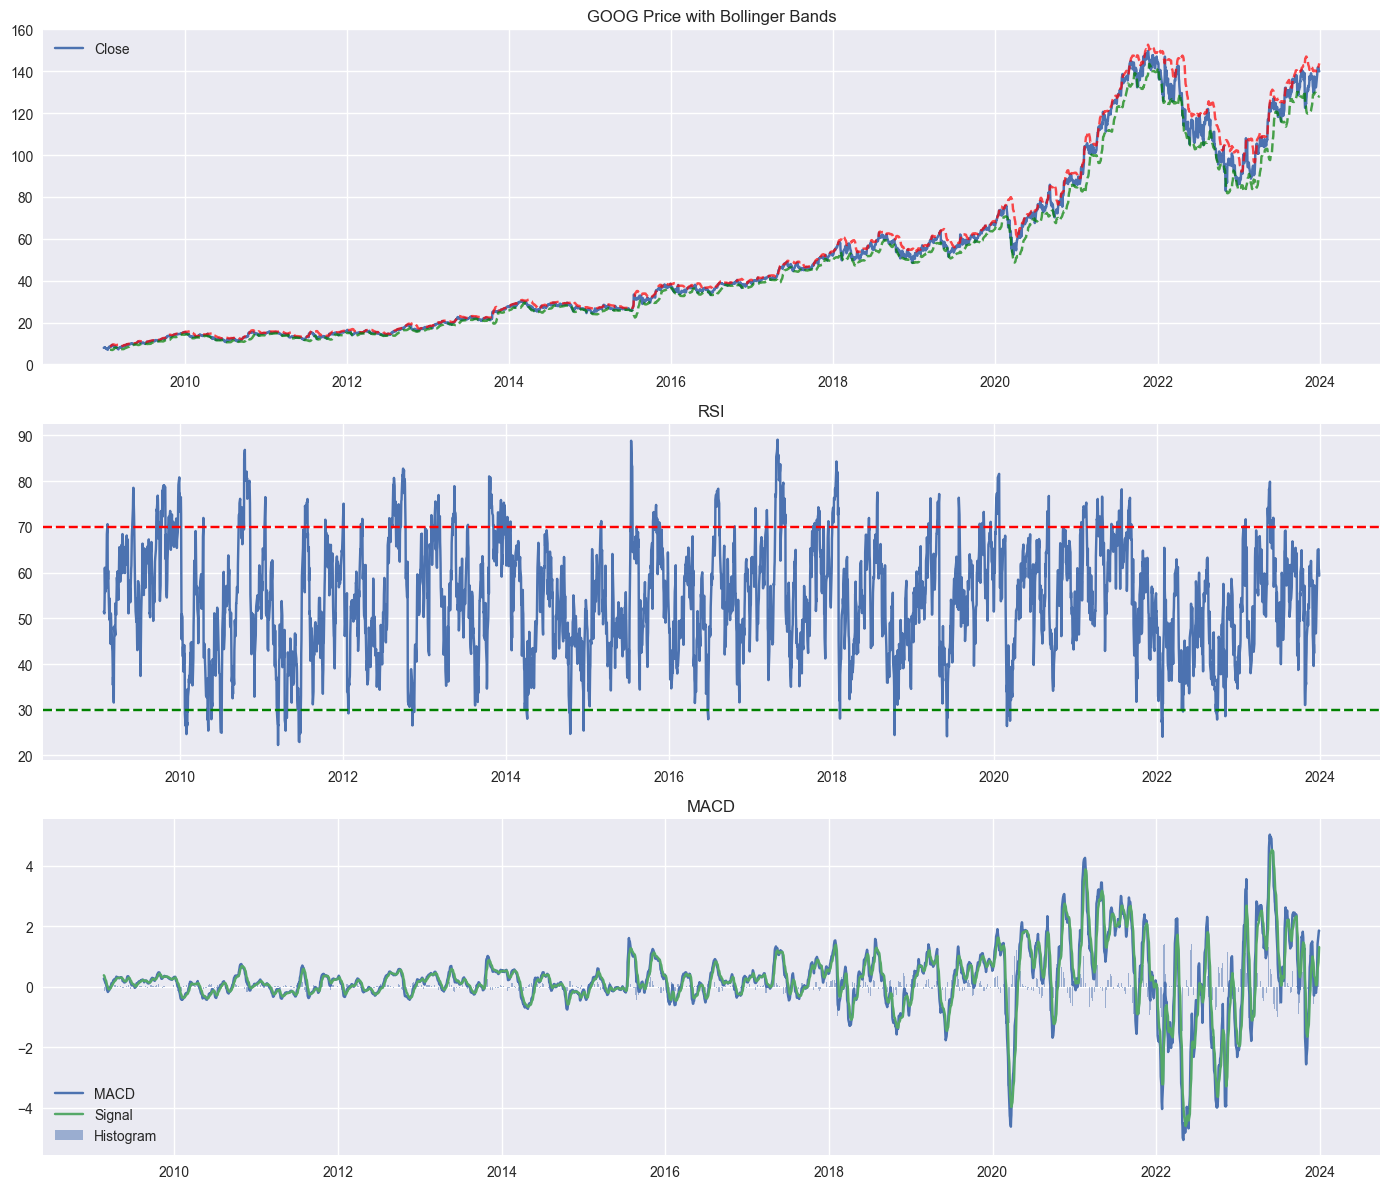

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Price + Bollinger Bands
axes[0].plot(stock.index, stock['Close'], label='Close')
axes[0].plot(stock.index, stock['BB_Upper'], 'r--', alpha=0.7)
axes[0].plot(stock.index, stock['BB_Lower'], 'g--', alpha=0.7)
axes[0].set_title('GOOG Price with Bollinger Bands')
axes[0].legend()

# RSI
axes[1].plot(stock.index, stock['RSI'])
axes[1].axhline(70, color='r', linestyle='--')
axes[1].axhline(30, color='g', linestyle='--')
axes[1].set_title('RSI')

# MACD
axes[2].plot(stock.index, stock['MACD'], label='MACD')
axes[2].plot(stock.index, stock['Signal'], label='Signal')
axes[2].bar(stock.index, stock['Histogram'], label='Histogram', alpha=0.5)
axes[2].set_title('MACD')
axes[2].legend()

plt.tight_layout()
plt.show()

In [6]:
# Get daily sentiment for GOOG
daily_sentiment = aggregate_daily_sentiment(news, 'GOOG')

print("Daily sentiment shape:", daily_sentiment.shape)
daily_sentiment.head()

Processing 1199 articles for GOOG...
why cant i see this?
Applying VADER to 1199 headlines...
getting sentiment for: Facebook, Snap Analyst Projects Q2 Revenue Upside For Social Media Stocks
scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
getting sentiment for: How Cannabis Company Cannaphyll Is Marketing On Mass-Consumer Platforms, Google And Amazon
scores: {'neg': 0.0, 'neu': 0.866, 'pos': 0.134, 'compound': 0.1779}
getting sentiment for: Twitter, Square Will Mark Juneteenth As Holiday To Honor African-American Culture
scores: {'neg': 0.0, 'neu': 0.604, 'pos': 0.396, 'compound': 0.7096}
getting sentiment for: Price Over Earnings Overview: Alphabet
scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
getting sentiment for: Google Maps To Offer Relevant Local COVID-19 Information For Public Transport, Driving And Testing Centers
scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
getting sentiment for: Starting This Week, Testing Center Alerts Will Be A

,date,avg_sentiment,pos,neg,neu,article_count,sentiment_category
0,2018-11-13,0.00000,0.00000,0.0000,1.00000,2,Neutral
1,2018-11-14,0.40370,0.20950,0.0000,0.79050,2,Positive
2,2018-11-15,0.21800,0.05175,0.0000,0.94825,4,Positive
3,2018-11-16,-0.10175,0.10750,0.2325,0.66000,2,Negative
4,2018-11-17,0.20230,0.13000,0.0000,0.87000,1,Positive


In [7]:
goog_news = news[news['stock'] == 'GOOG'].copy()
print("Rows for GOOG:", len(goog_news))
print("Null headlines:", goog_news['headline'].isna().sum())
print(goog_news['headline'].head(10))

Rows for GOOG: 1199
Null headlines: 0
568379    Facebook, Snap Analyst Projects Q2 Revenue Ups...
568380    How Cannabis Company Cannaphyll Is Marketing O...
568381    Twitter, Square Will Mark Juneteenth As Holida...
568382               Price Over Earnings Overview: Alphabet
568383    Google Maps To Offer Relevant Local COVID-19 I...
568384    Starting This Week, Testing Center Alerts Will...
568385    CNBC Publishes Article Titled: States are Lean...
568386    Congress Is Stepping Up Its Efforts To Kill Pa...
568387    Twitter Takes Down Trump Campaign's Video Trib...
568388    UPDATE: Chinese Government-Linked Hackers Rece...
Name: headline, dtype: object


In [8]:
# === Prepare Stock Data ===
stock_daily = stock[['Daily_Return']].copy()
stock_daily = stock_daily.reset_index()

# Make sure date column is in the same format (date only)
stock_daily['date'] = pd.to_datetime(stock_daily['Date']).dt.date

print("Stock days:", len(stock_daily))
print("Sentiment days:", len(daily_sentiment))

# === Merge Sentiment + Stock Returns ===
merged = pd.merge(
    daily_sentiment,
    stock_daily,
    on='date',
    how='inner'          # Only keep days where we have BOTH news and stock data
)

print("✅ Merged shape:", merged.shape)
print("Date range:", merged['date'].min(), "to", merged['date'].max())

merged.head()

Stock days: 3774
Sentiment days: 377
✅ Merged shape: (352, 9)
Date range: 2018-11-13 to 2020-06-10


,date,avg_sentiment,pos,neg,neu,article_count,sentiment_category,Date,Daily_Return
0,2018-11-13,0.00000,0.00000,0.0000,1.00000,2,Neutral,2018-11-13,-0.248399
1,2018-11-14,0.40370,0.20950,0.0000,0.79050,2,Positive,2018-11-14,0.734507
2,2018-11-15,0.21800,0.05175,0.0000,0.94825,4,Positive,2018-11-15,2.016938
3,2018-11-16,-0.10175,0.10750,0.2325,0.66000,2,Negative,2018-11-16,-0.302427
4,2018-11-19,-0.08030,0.11300,0.1220,0.76500,1,Negative,2018-11-19,-3.908660


=== Average Daily Return by Sentiment Category ===

                    Daily_Return  num_days
sentiment_category                        
Negative                 -0.8042        72
Neutral                   0.1353       111
Positive                  0.5558       169


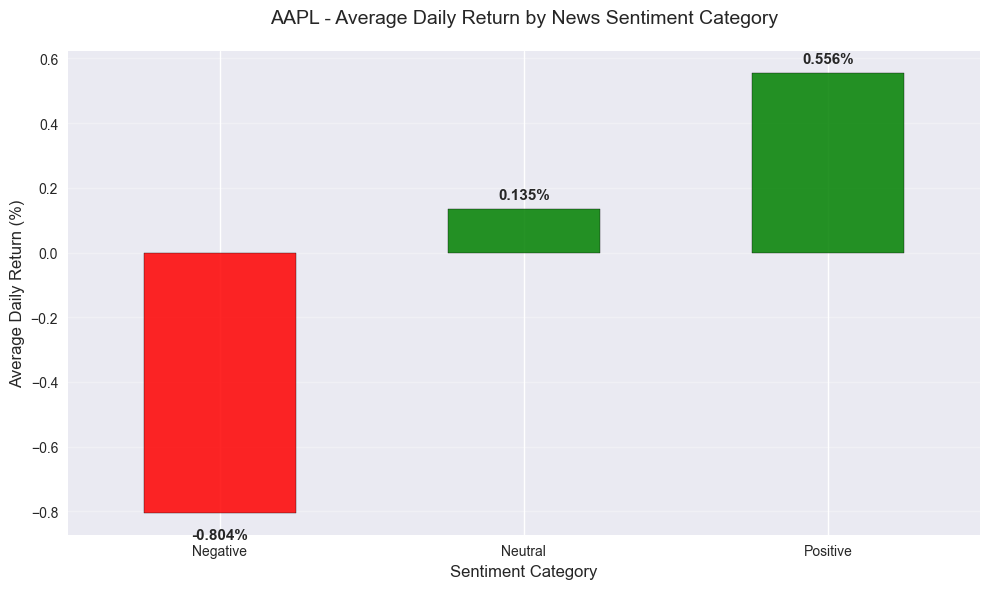

In [9]:
# Average Daily Return by Sentiment
avg_return = merged.groupby('sentiment_category')['Daily_Return'].mean().round(4)
count_per_category = merged.groupby('sentiment_category').size()

print("=== Average Daily Return by Sentiment Category ===\n")
result = pd.concat([avg_return, count_per_category.rename('num_days')], axis=1)
print(result)

# === Bar Chart ===
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in avg_return]

bars = avg_return.plot(kind='bar', color=colors, alpha=0.85, edgecolor='black')

plt.title('AAPL - Average Daily Return by News Sentiment Category', fontsize=14, pad=20)
plt.ylabel('Average Daily Return (%)', fontsize=12)
plt.xlabel('Sentiment Category', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(avg_return):
    plt.text(i, v + (0.03 if v >= 0 else -0.08), 
             f"{v:.3f}%", 
             ha='center', 
             fontsize=11, 
             fontweight='bold')

plt.tight_layout()
plt.show()

Correlation between Average Sentiment Score and Daily Return: 0.1895


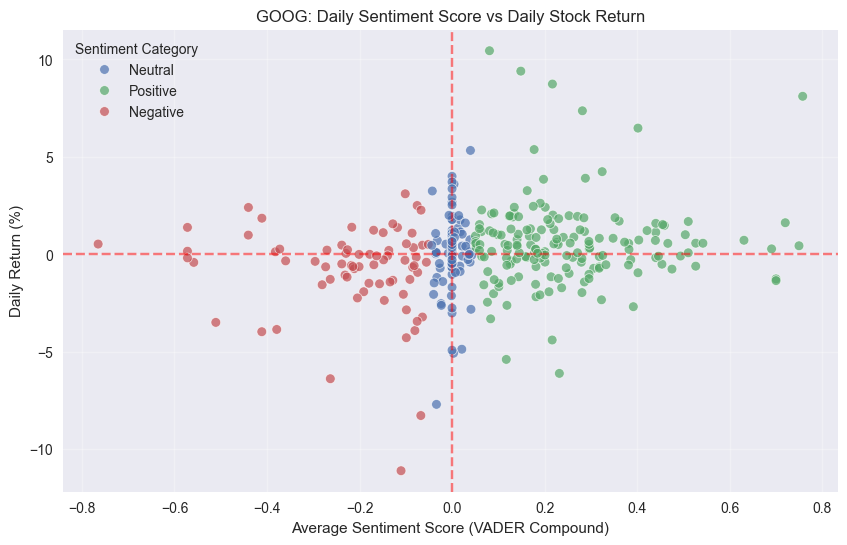

In [10]:
# Correlation
correlation = merged['avg_sentiment'].corr(merged['Daily_Return'])
print(f"Correlation between Average Sentiment Score and Daily Return: {correlation:.4f}")

# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='avg_sentiment', y='Daily_Return', alpha=0.7, hue='sentiment_category')
plt.title('GOOG: Daily Sentiment Score vs Daily Stock Return')
plt.xlabel('Average Sentiment Score (VADER Compound)')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend(title='Sentiment Category')
plt.show()

In [11]:
print("=== Summary Statistics GOOG ===")
print(f"Total trading days with news: {len(merged)}")
print(f"Positive sentiment days : {count_per_category.get('Positive', 0)}")
print(f"Neutral sentiment days  : {count_per_category.get('Neutral', 0)}")
print(f"Negative sentiment days : {count_per_category.get('Negative', 0)}")
print(f"Best average return     : {avg_return.max():.3f}% on {avg_return.idxmax()}")
print(f"Worst average return    : {avg_return.min():.3f}% on {avg_return.idxmin()}")

=== Summary Statistics GOOG ===
Total trading days with news: 352
Positive sentiment days : 169
Neutral sentiment days  : 111
Negative sentiment days : 72
Best average return     : 0.556% on Positive
Worst average return    : -0.804% on Negative
